<img src='http://www-scf.usc.edu/~ghasemig/images/sharif.png' alt="SUT logo" width=300 height=300 align=left class="saturate" >

<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2024<br>
<font color=3C99D size=5>
    Practical Assignment 1 - Search <br>
<font color=696880 size=4>
<div dir=ltr>
Dorsa Ghobadi



____

# Personal Data

In [1]:
# Set your student number
student_number = '401102789'
Name = 'Seyed Ali'
Last_Name = 'Vakilzadeh Hatefi'

# Rules
- Make sure that all of your cells can be run perfectly.
-Do not change the Parts which are not marked with #TODO
-Complete the functions or parts that are marked with #TODO
-Feel free to add functions if you need!

## Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from queue import Queue, LifoQueue, PriorityQueue
import random


# Uninformed & Informed Search

<font size=4>
Author: Dorsa Ghobadi
			<br/>
                <font color=red>
Please run all the cells.
     </font>
</font>
                <br/>
    </div>

## Problem Definition

In This Problem, We want to investigate Maze Problem with the focus on implementing BFS,DFS and A-Star algorithm to solve it. This notebook is inspired by the [pacman](https://freepacman.org/) game. We generate a random maze and put the pacman in the top left crner and the food in the bottom right corner. The goal is to find a way from the pacman to the food using different search algorithms.



## Code

In [3]:
def generate_maze(rows, cols, wall_prob=0.3):
    np.random.seed(40)
    maze = np.random.choice([0, 1], size=(rows, cols), p=[1-wall_prob, wall_prob])
    start = (0, 0)
    goal = (rows-1, cols-1)
    maze[start] = 0
    maze[goal] = 0
    return maze, start, goal

def plot_maze(maze, path=None, start=None, goal=None):
    plt.imshow(maze, cmap="gray")
    if path:
        x, y = zip(*path)
        plt.plot(y, x, color='yellow', linewidth=2)  # Plot path in yellow
    if start:
        plt.scatter(start[1], start[0], color='blue', s=100, label='Pacman')  # Pacman start
    if goal:
        plt.scatter(goal[1], goal[0], color='green', s=100, label='Food')  # Food
    plt.legend()
    plt.show()

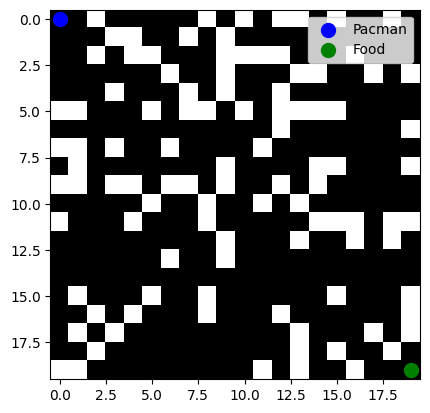

In [4]:
rows, cols = 20, 20
maze, start, goal = generate_maze(rows, cols)
plot_maze(maze, start=start, goal=goal)


In [5]:
class SearchAlgorithm:
    # def find_path(self, start, goal, parents):
    #   path=[]
    #   current=goal
    #   while( current != start):
    #     path.append(current)
    #     current= parents[current]
    #   path.append(start)
    #   return path

    def find_path(self,start, goal, parents_X, parents_Y):
      path=[]
      current=goal
      while(current != start):
        path.append(current)
        current = (parents_Y[current], parents_X[current])
      path.append(start)
      return path

    def __init__(self, maze):
        self.maze = maze
        self.rows, self.cols = maze.shape
        self.visited = np.zeros_like(maze)
        self.expanded_nodes = 0

    def get_neighbors(self, pos):
        neighbors = []
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # Right, Down, Left, Up
        for d in directions:
            new_pos = (pos[0] + d[0], pos[1] + d[1])
            if 0 <= new_pos[0] < self.rows and 0 <= new_pos[1] < self.cols and not self.maze[new_pos] and not self.visited[new_pos]:
                neighbors.append(new_pos)
        return neighbors


In [6]:
def plot_algorithm(maze, start, goal,name,algorithm):
  path = algorithm.search(start, goal)
  result = {'path': path, 'expanded_nodes': algorithm.expanded_nodes}
  print(f"{name}: Expanded Nodes = {algorithm.expanded_nodes}")
  plot_maze(maze, path, start, goal)



In [7]:
class DFS(SearchAlgorithm):
    def next_dfs(self, current, parent, goal, parentsX, parentsY):
        self.visited[current]=1
        self.expanded_nodes+=1
        parentsY[current], parentsX[current]=parent
        if(self.visited[goal] == 1): #end condition
          return True

        for neighbor in self.get_neighbors(current):
           if(self.next_dfs(neighbor, current, goal, parentsX, parentsY)):
              return True
        return False


    def search(self, start, goal):
        self.expanded_nodes=0
        self.visited= np.zeros_like(maze)
        parentsX= np.zeros_like(maze)
        parentsY= np.zeros_like(maze)
        self.next_dfs( start, start , goal, parentsX, parentsY)
        return self.find_path(start, goal,  parentsX, parentsY)


DFS: Expanded Nodes = 63


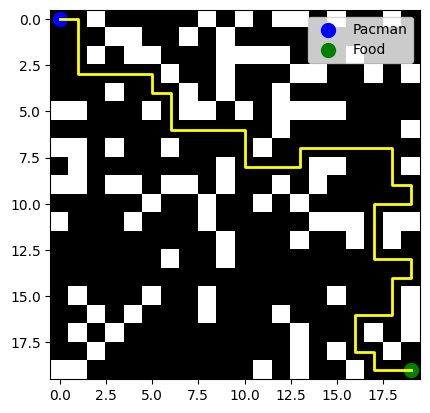

In [8]:
plot_algorithm(maze,start,goal,'DFS', DFS(maze))

In [9]:
from collections import deque
class BFS(SearchAlgorithm):

    def search(self, start, goal):
        parents_X = np.full_like(maze, -1)
        parents_Y = np.full_like(maze, -1)
        visiting_queue=deque([])
        self.expanded_nodes=0
        self.visited=np.zeros_like(maze)

        parents_Y[start], parents_X[start]= start
        visiting_queue.append(start)

        while(visiting_queue):
          current_node=visiting_queue.popleft()
          self.visited[current_node]=1
          self.expanded_nodes+=1

          if(self.visited[goal]==1):
            return self.find_path(start, goal, parents_X, parents_Y)

          for coord in self.get_neighbors(current_node):
            if(parents_X[coord] == -1):
              parents_Y[coord], parents_X[coord]=current_node
              visiting_queue.append(coord)
        return None

BFS: Expanded Nodes = 280


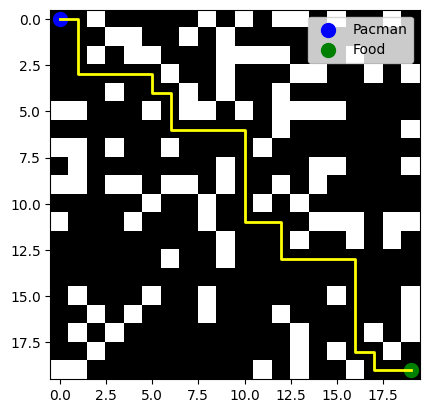

In [10]:
plot_algorithm(maze,start,goal,'BFS', BFS(maze))

Question:

So far, we have explored three uninformed search methods: DFS, BFS. Briefly explain the advantages and disadvantages of each method in the context of the Maze Problem and compare their performance based on your observations (consider both time and memory).

In [11]:
import heapq

class AStar(SearchAlgorithm):
    def heuristic(self, pos, goal): #manhattan approximation
      return abs(goal[1]-pos[1])+abs(goal[0]-pos[0])

    def search(self, start, goal):
        gcosts=np.full(maze.shape, np.inf)  # Track the g(x) for each node
        parents_X = np.full_like(maze, -1)
        parents_Y = np.full_like(maze, -1)
        min_heap=[] #for keeping the cost function values of each node: h(x) + g(x)
        heapq.heappush(min_heap, (0, start))  # Start node with cost 0
        gcosts[start] = 0
        while(len(min_heap) != 0):
          current_cost, current = heapq.heappop(min_heap) #get the value and position of new best node
          current_cost -= self.heuristic(current, goal) #change f to g for further uses

          if (self.visited[current] == 1):
                continue
          self.visited[current] = 1
          self.expanded_nodes += 1

          if (self.visited[goal]==1): #end condition
            return self.find_path(start, goal, parents_X, parents_Y)

          new_cost = current_cost + 1  #possible g(x) optimization for neighbors
          for coord in self.get_neighbors(current):
            # Only do these if the new g(x) cost is better
            if new_cost < gcosts[coord]:
              gcosts[coord] = new_cost
              heapq.heappush(min_heap, (new_cost + self.heuristic(coord , goal) , (coord))) #push with updated value of f because of g(x)
              parents_Y[coord], parents_X[coord]=current

        return None



A*: Expanded Nodes = 169


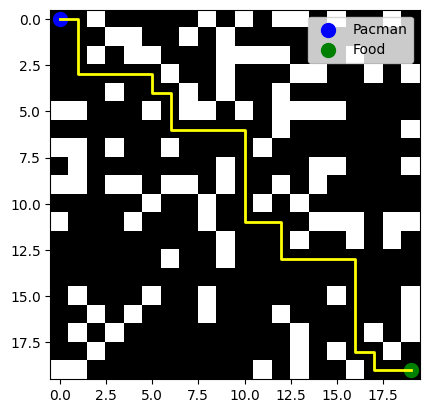

In [12]:
plot_algorithm(maze,start,goal,'A*', AStar(maze))

Question:

Explain your heuristic and observation's result. Also, compare the A* method with Uniformed search in the context of the Maze problem.

as we can see in the maze, only moves in four directions of right, left up and down are alowed. This implies that using manhattan distance of two nodes can result in a good approximation, which is always admissible since there are walls involved and we can not always move towards goal ncessarily.

Now we want to explore a situation where each cell of the maze has an entrance cost, which means in order to enter that cell we must pay a fixed price. you should implement the above search algorithms with the least payed cost.

In [13]:
def generate_maze_with_costs(rows, cols, wall_prob=0.3):
    np.random.seed(137)
    maze = np.random.choice([0, 1], size=(rows, cols), p=[1-wall_prob, wall_prob])
    costs = np.random.randint(1, 11, size=(rows, cols))
    start = (0, 0)
    goal = (rows-1, cols-1)
    maze[start] = 0
    maze[goal] = 0
    return maze, costs, start, goal

def plot_maze_with_costs(maze, costs, path=None, start=None, goal=None):
    plt.imshow(maze, cmap="gray", vmin=0, vmax=1)

    for i in range(maze.shape[0]):
        for j in range(maze.shape[1]):
            if maze[i, j] == 0:
                cl = 'red' if costs[i,j] > 6 else ('green' if costs[i,j] < 4 else 'orange')
                plt.text(j, i, str(costs[i, j]), ha='center', va='center', color=cl, fontsize=8)

    if path:
        x, y = zip(*path)
        plt.plot(y, x, color='yellow', linewidth=2)  # Plot path in yellow
    if start:
        plt.scatter(start[1], start[0], color='blue', s=100, label='Pacman')  # Pacman start
    if goal:
        plt.scatter(goal[1], goal[0], color='pink', s=100, label='Food')  # Food
    plt.legend()
    plt.show()


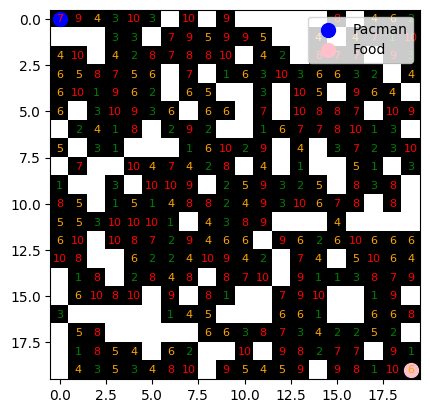

In [14]:
rows, cols = 20, 20
maze, costs, start, goal = generate_maze_with_costs(rows, cols)
plot_maze_with_costs(maze, costs, start=start, goal=goal)

In [15]:
# Search Algorithms
class SearchAlgorithmWithCosts:
    def __init__(self, maze, costs):
        self.maze = maze
        self.costs = costs
        self.rows, self.cols = maze.shape
        self.visited = np.zeros_like(maze)
        self.expanded_nodes = 0

    def get_neighbors(self, pos):
        neighbors = []
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # Right, Down, Left, Up
        for d in directions:
            new_pos = (pos[0] + d[0], pos[1] + d[1])
            if 0 <= new_pos[0] < self.rows and 0 <= new_pos[1] < self.cols and not self.maze[new_pos] and not self.visited[new_pos]:
                neighbors.append(new_pos)
        return neighbors

    def calculate_total_cost(self, path):
        return sum(self.costs[pos] for pos in path)

    def get_path(self, start, goal, parents_X, parents_Y):
      path=[]
      current=goal
      while(current != start):
        path.append(current)
        current = (parents_Y[current], parents_X[current])
      path.append(start)
      return path


In [16]:
def plot_algorithms_with_costs(maze, costs, start, goal,name,algorithm):
    path, total_cost = algorithm.search(start, goal)
    result = {'path': path, 'expanded_nodes': algorithm.expanded_nodes, 'total_cost': total_cost}
    print(f"{name}: Expanded Nodes = {algorithm.expanded_nodes}, Total Cost = {total_cost}")
    plot_maze_with_costs(maze, costs, path, start, goal)


In [17]:
class DFSWithCosts(SearchAlgorithmWithCosts):
    def next_dfs(self, current, parent, goal, parentsX, parentsY):
        self.visited[current]=1
        self.expanded_nodes+=1
        parentsY[current], parentsX[current]=parent
        if(self.visited[goal] == 1): #end condition
          return True

        for neighbor in self.get_neighbors(current):
           if(self.next_dfs(neighbor, current, goal, parentsX, parentsY)):
             return True
        return False


    def search(self, start, goal):
        #TODO: implement DFS search
        #returns the best path(list of tuples) and best cost(int)
        self.expanded_nodes=0
        self.visited= np.zeros_like(maze)
        parentsX= np.zeros_like(maze)
        parentsY= np.zeros_like(maze)
               #not reaching goal:
        best_cost = float('inf')
        best_path = None
        if(self.next_dfs( start, start , goal, parentsX, parentsY)):
            best_path=self.get_path(start, goal, parentsX, parentsY)
            best_cost=self.calculate_total_cost(best_path)
        return best_path, best_cost


DFS: Expanded Nodes = 54, Total Cost = 265


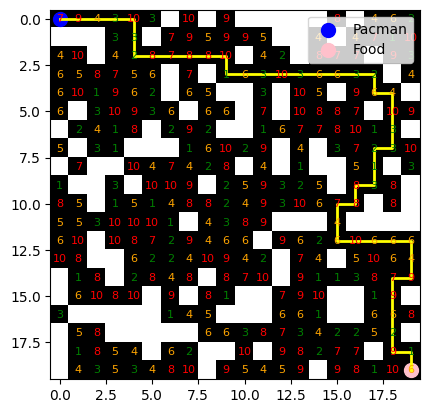

In [18]:
plot_algorithms_with_costs(maze, costs, start, goal,'DFS',DFSWithCosts(maze,costs))

In [19]:
# BFS Algorithm with Costs
class BFSWithCosts(SearchAlgorithmWithCosts):
    def search(self, start, goal):
        parents_X = np.full_like(maze, -1)
        parents_Y = np.full_like(maze, -1)
        visiting_queue=deque([])
        self.expanded_nodes=0
        self.visited=np.zeros_like(maze)
        best_cost = float('inf')
        best_path = None

        parents_Y[start], parents_X[start]= start
        visiting_queue.append(start)

        while(visiting_queue):
          current_node=visiting_queue.popleft()
          self.visited[current_node]=1
          self.expanded_nodes+=1

          if(self.visited[goal]==1):
            best_path= self.get_path(start, goal, parents_X, parents_Y)
            best_cost= self.calculate_total_cost(best_path)
            return best_path, best_cost

          for coord in self.get_neighbors(current_node):
            if(parents_X[coord] == -1):
              parents_Y[coord], parents_X[coord]=current_node
              visiting_queue.append(coord)
        return best_path, best_cost


BFS: Expanded Nodes = 267, Total Cost = 232


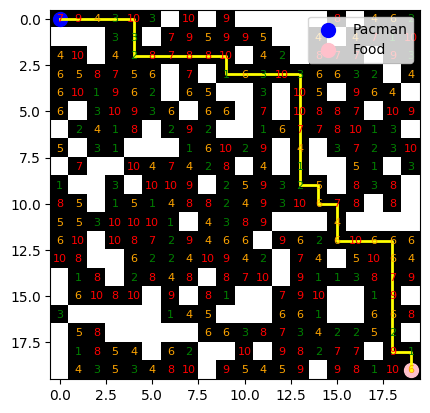

In [20]:
plot_algorithms_with_costs(maze, costs, start, goal,'BFS',BFSWithCosts(maze,costs))

In [21]:
# A* Algorithm with Costs
class AStarWithCosts(SearchAlgorithmWithCosts):
    def heuristic(self, pos, goal):
      return abs(goal[1]-pos[1])+abs(goal[0]-pos[0]) #cant have a factor for better accuracy because we have to gurantee a lower bound

    def search(self, start, goal):
        best_cost = float('inf')
        best_path = None
        gcosts=np.full(maze.shape, np.inf)  # Track the g(x) for each node
        parents_X = np.full_like(maze, -1)
        parents_Y = np.full_like(maze, -1)
        min_heap=[] #for keeping the cost function values of each node: h(x) + g(x)
        heapq.heappush(min_heap, (0, start))  # Start node with cost 0
        gcosts[start] = 0
        while(len(min_heap) != 0):
          current_cost, current = heapq.heappop(min_heap) #get the value and position of new best node
          current_cost -= self.heuristic(current, goal) #change f to g for further uses

          if (self.visited[current] == 1):
                continue
          self.visited[current] = 1
          self.expanded_nodes += 1

          if (self.visited[goal]==1): #end condition
            best_path= self.get_path(start, goal, parents_X, parents_Y)
            best_cost=self.calculate_total_cost(best_path)
            return best_path, best_cost

          new_cost = current_cost + self.costs[current]  #possible g(x) optimization for neighbors, this time with weight of older node included
          for coord in self.get_neighbors(current):
            # Only do these if the new g(x) cost is better
            if new_cost < gcosts[coord]:
              gcosts[coord] = new_cost
              heapq.heappush(min_heap, (new_cost + self.heuristic(coord , goal) , (coord))) #push with updated value of f because of g(x)
              parents_Y[coord], parents_X[coord]=current

        return best_path, best_cost


A*: Expanded Nodes = 268, Total Cost = 177


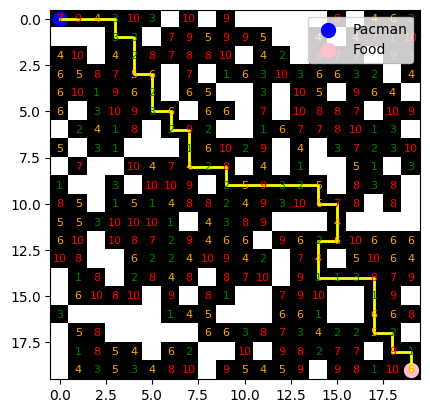

In [22]:
plot_algorithms_with_costs(maze, costs, start, goal,'A*',AStarWithCosts(maze,costs))

Question:

now that you have explored these methods(DFS, BFS,A star) in priced manner, Briefly explain the advantages and disadvantages of each method in the context of the Maze Problem and compare their performance based on your observations.

A* is will always gurantee an optimal solution, whereas uninformed search method of bfs (as its original form) will only yield to optimal solution without weights included.
dfs however, is a lazy method of searching in our solution which can result in very high runtimes (althought it didnt occur here and it was seemingly better than bfs) and answers that are not optimal. dfs however, has lower space complexity than bfs.
As a wrap, A* is an optimal superior algorithm to both of the uninformed searches discussed